# Proyecto Final Integrador — Predicción de Default de Préstamos (Loan Default)

**Dataset**: Kaggle — *Loan Defaults* (joebeachcapital).  
Objetivo: **predecir el default de un préstamo** antes de otorgarlo, para reducir pérdidas.

Link: https://www.kaggle.com/datasets/joebeachcapital/loan-default

---

## Metodología: CRISP-DM

1) **Business Understanding**  
2) **Data Understanding**  
3) **Data Preparation**  
4) **Modeling**  
5) **Evaluation**  
6) **Deployment (propuesta / mock)**

---

## 1) Business Understanding (entendimiento del negocio)

### Problema de negocio
Una entidad financiera quiere **reducir pérdidas** por préstamos que terminan en **default**.  
La predicción se usará para:
- ajustar políticas de aprobación (rechazar solicitudes de alto riesgo),
- ajustar pricing (tasa) o límites de crédito,
- priorizar estrategias de prevención (alertas tempranas).

### KPI(s) de negocio (impacto)
- Reducir **Expected Loss** (pérdida esperada) y/o pérdidas por default.
- Alternativamente: aumentar utilidad neta al tomar mejores decisiones.

### KPI(s) técnicos (para evaluar el modelo)
Como el default suele ser la clase minoritaria y el costo del error es asimétrico:
- Métrica principal: **PR-AUC** (Average Precision) y **Recall de Default**.
- Métrica secundaria: **ROC-AUC**, **F1**, **Precision**.

### Riesgo operativo clave (asimetría de costos)
- **Falso Negativo (FN)**: aprobar a alguien que luego cae en default → costo alto (pérdida directa).
- **Falso Positivo (FP)**: rechazar a un buen pagador → costo oportunidad (menor que FN).
Por eso, además de medir métricas, se elegirá un **umbral (threshold) óptimo** basado en costos.

---


In [ ]:
!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 250)

df = pd.read_csv(
    "/content/Anonymize_Loan_Default_data.csv",
    sep=";",
    encoding="latin1"
)

df.head()

,#,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,repay_fail
0,3,545583,703644,2500.0,2500.0,2500.0,36 months,13.98,85.42,4 years,RENT,20004.0,Not Verified,jul-10,Does not meet the credit policy. Status:Fully ...,other,487xx,MI,19.86,0.0,Aug-05,5.0,NaN,7.0,0.0,981.0,21.30%,10.0,3075.291779,3075.29,2500.00,575.29,jul-13,90.85,Aug-13,jun-16,0
1,4,532101,687836,5000.0,5000.0,5000.0,36 months,15.95,175.67,4 years,RENT,59000.0,Not Verified,jun-10,Charged Off,debt_consolidation,115xx,NY,19.57,0.0,Apr-94,1.0,59.0,7.0,0.0,18773.0,99.90%,15.0,2948.760000,2948.76,1909.02,873.81,nov-11,175.67,NaN,mar-12,1
2,5,877788,1092507,7000.0,7000.0,7000.0,36 months,9.91,225.58,10+ years,MORTGAGE,53796.0,Not Verified,sept-11,Fully Paid,other,751xx,TX,10.80,3.0,mar-98,3.0,3.0,7.0,0.0,3269.0,47.20%,20.0,8082.391880,8082.39,7000.00,1082.39,mar-14,1550.27,NaN,mar-14,0
3,6,875406,1089981,2000.0,2000.0,2000.0,36 months,5.42,60.32,10+ years,RENT,30000.0,Not Verified,sept-11,Fully Paid,debt_consolidation,112xx,NY,3.60,0.0,Jan-75,0.0,72.0,7.0,0.0,0.0,0%,15.0,2161.663244,2161.66,2000.00,161.66,feb-14,53.12,NaN,jun-16,0
4,7,506439,652909,3600.0,3600.0,3600.0,36 months,10.25,116.59,10+ years,MORTGAGE,675048.0,Not Verified,Apr-10,Does not meet the credit policy. Status:Fully ...,other,352xx,AL,1.55,0.0,Apr-98,4.0,25.0,8.0,0.0,0.0,0%,25.0,4206.031191,4206.03,3600.00,606.03,may-13,146.75,jun-13,jun-16,0


## 2) Data Understanding (entendimiento de los datos)

En esta etapa se:
- inspeccionan las columnas y tipos,
- estima la tasa de default (desbalance),
- arma un “diccionario mínimo” (top 10 variables más relevantes para el caso),
- detecta problemas de calidad: nulos, duplicados, outliers y categorías raras.

**Nota:** el dataset está anonimizado, por lo que no siempre se puede interpretar semánticamente cada columna. Sin embargo, el flujo sigue siendo válido y replicable.

In [ ]:
def detect_target_column(cols):
    cols_l = [c.lower() for c in cols]
    # candidatos típicos en default/loan status
    for cand in ["loan_status", "default", "is_default", "status", "target", "y"]:
        if cand in cols_l:
            return cols[cols_l.index(cand)]
    # fallback: buscar palabra default
    for c in cols:
        if "default" in c.lower():
            return c
    # último recurso
    return cols[-1]

target_col = detect_target_column(list(df.columns))
print("Target detectado:", target_col)

def normalize_target_to_01(s: pd.Series) -> pd.Series:
    # si ya es 0/1 numérico
    if s.dtype.kind in "biufc":
        uniq = set(pd.Series(s.dropna().unique()).tolist())
        if uniq <= {0, 1}:
            return s.astype(int)
        # si viene como {1,2} o similar
        if uniq <= {1, 2}:
            return (s == 2).astype(int)
        # fallback
        return (s > 0).astype(int)

    # si es texto/categórico
    sl = s.astype(str).str.lower().str.strip()

    # mapeos típicos de LendingClub / loan datasets
    # default=1 cuando es "charged off", "default", "late", etc.
    default_keywords = [
        "charged off", "default", "late", "late (16-30 days)", "late (31-120 days)",
        "in grace period", "delinquent", "bad", "writeoff", "write-off"
    ]
    nondefault_keywords = ["fully paid", "current", "paid", "good", "complete"]

    y01 = np.zeros(len(sl), dtype=int)
    for i, v in enumerate(sl):
        if any(k in v for k in default_keywords):
            y01[i] = 1
        elif any(k in v for k in nondefault_keywords):
            y01[i] = 0
        else:
            # si no matchea, tratamos valores "1/0", "yes/no", etc.
            if v in {"1", "yes", "y", "true"}:
                y01[i] = 1
            else:
                y01[i] = 0
    return pd.Series(y01, index=s.index)

y = normalize_target_to_01(df[target_col])
X = df.drop(columns=[target_col])

print("\nDistribución del target (0=no default, 1=default):")
display(y.value_counts())
print("Default rate:", round(float(y.mean()), 4))

Target detectado: loan_status

Distribución del target (0=no default, 1=default):


,count
0,32636
1,5843


Default rate: 0.1518


In [ ]:
print("=== Data Quality Report ===")

# tipos
display(df.dtypes.value_counts().rename("count"))

# duplicados
dup = df.duplicated().sum()
print("Duplicados:", dup)

# nulos (top 15)
null_pct = df.isna().mean().sort_values(ascending=False)
display((null_pct.head(15) * 100).round(2).rename("% nulos top 15"))

# diccionario mínimo (top 10 variables por completitud + diversidad)
# (para el informe: nombre, tipo, %nulos, #valores únicos)
dic = pd.DataFrame({
    "columna": X.columns,
    "tipo": [str(X[c].dtype) for c in X.columns],
    "%nulos": (X.isna().mean().values * 100),
    "n_unicos": [X[c].nunique(dropna=True) for c in X.columns]
}).sort_values(["%nulos", "n_unicos"], ascending=[True, False])

print("Diccionario mínimo (top 10 variables sugeridas):")
display(dic.head(10))

# outliers rápidos en numéricas (IQR)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    out_counts = {}
    for c in num_cols:
        s = X[c].dropna()
        if len(s) < 50:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            continue
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        out_counts[c] = int(((s < lo) | (s > hi)).sum())
    if out_counts:
        display(pd.Series(out_counts).sort_values(ascending=False).head(10).rename("outliers_IQR_top10"))

=== Data Quality Report ===


,count
float64,19
object,14
int64,4


Duplicados: 0


,% nulos top 15
next_pymnt_d,91.21
mths_since_last_delinq,63.31
emp_length,2.58
last_pymnt_d,0.18
revol_util,0.15
revol_bal,0.01
last_credit_pull_d,0.01
annual_inc,0.01
total_rec_int,0.00
funded_amnt,0.00


Diccionario mínimo (top 10 variables sugeridas):


,columna,tipo,%nulos,n_unicos
0,#,int64,0.0,38479
1,id,int64,0.0,38479
2,member_id,int64,0.0,38479
17,dti,float64,0.0,2878
15,zip_code,object,0.0,833
19,earliest_cr_line,object,0.0,528
7,int_rate,float64,0.0,391
13,issue_d,object,0.0,56
16,addr_state,object,0.0,51
14,purpose,object,0.0,14


,outliers_IQR_top10
last_pymnt_amnt,4239
total_rec_int,3026
revol_bal,2624
annual_inc,1844
total_pymnt_inv,1400
total_pymnt,1266
installment,1232
loan_amnt,1103
funded_amnt_inv,1043
funded_amnt,931


## EDA (Exploratory Data Analysis)

Se realiza un EDA mínimo orientado a negocio:
- distribución del target (para evidenciar desbalance),
- correlaciones numéricas simples con el target,
- ejemplos de variables con señal (si aplica).

Objetivo: **demostrar viabilidad del problema** y documentar patrones relevantes.

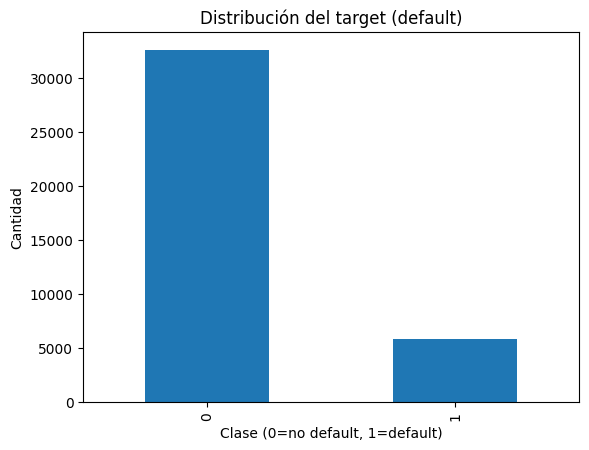

Top 10 correlaciones absolutas (numéricas) con target:


,corr,abs_corr
repay_fail,0.998486,0.998486
total_rec_prncp,-0.342460,0.342460
total_pymnt,-0.245988,0.245988
total_pymnt_inv,-0.243533,0.243533
last_pymnt_amnt,-0.220630,0.220630
int_rate,0.200865,0.200865
inq_last_6mths,0.111511,0.111511
pub_rec,0.050597,0.050597
loan_amnt,0.043279,0.043279
dti,0.042504,0.042504


In [ ]:
# Distribución target
plt.figure()
y.value_counts().plot(kind="bar")
plt.title("Distribución del target (default)")
plt.xlabel("Clase (0=no default, 1=default)")
plt.ylabel("Cantidad")
plt.show()

# Correlación simple numéricas vs target (top 10 abs)
if num_cols:
    corr = pd.concat([X[num_cols], y.rename("target")], axis=1).corr(numeric_only=True)["target"].drop("target")
    corr_abs = corr.abs().sort_values(ascending=False).head(10)
    print("Top 10 correlaciones absolutas (numéricas) con target:")
    display(pd.DataFrame({"corr": corr.loc[corr_abs.index], "abs_corr": corr_abs}))

## 3) Data Preparation (preparación)

Esta etapa incluye:
- separación de variables numéricas y categóricas,
- imputación de nulos (mediana para numéricas, moda para categóricas),
- encoding de categóricas (One-Hot),
- escalado (para modelos lineales),
- creación de **features financieras** si existen columnas típicas (ej. ratios con ingreso).

**Feature engineering financiero (si están disponibles):**
- `loan_income_ratio = loan_amnt / annual_inc`
- `installment_income_ratio = installment*12 / annual_inc`
- `int_rate_x_amount = int_rate * loan_amnt` (proxy de carga financiera)

Estas variables suelen capturar mejor el riesgo que las columnas originales de forma aislada.

In [ ]:
X_fe = X.copy()

# Helpers: buscar columnas por nombre aproximado (porque puede variar en el CSV)
def find_col_like(candidates):
    cols_l = {c.lower(): c for c in X_fe.columns}
    for cand in candidates:
        if cand in cols_l:
            return cols_l[cand]
    # búsqueda parcial
    for c in X_fe.columns:
        cl = c.lower()
        if any(cand in cl for cand in candidates):
            return c
    return None

col_loan = find_col_like(["loan_amnt", "loan_amount", "amount", "loanamt"])
col_inc  = find_col_like(["annual_inc", "income", "annualincome"])
col_inst = find_col_like(["installment", "instalment", "payment"])
col_rate = find_col_like(["int_rate", "interest_rate", "rate"])

# Crear ratios solo si existen y son numéricas
def safe_div(a, b):
    return np.where((b is None) | (pd.isna(b)) | (b == 0), np.nan, a / b)

created = []
if col_loan and col_inc and (pd.api.types.is_numeric_dtype(X_fe[col_loan])) and (pd.api.types.is_numeric_dtype(X_fe[col_inc])):
    X_fe["loan_income_ratio"] = X_fe[col_loan] / X_fe[col_inc].replace(0, np.nan)
    created.append("loan_income_ratio")

if col_inst and col_inc and (pd.api.types.is_numeric_dtype(X_fe[col_inst])) and (pd.api.types.is_numeric_dtype(X_fe[col_inc])):
    X_fe["installment_income_ratio"] = (X_fe[col_inst] * 12) / X_fe[col_inc].replace(0, np.nan)
    created.append("installment_income_ratio")

if col_rate and col_loan and (pd.api.types.is_numeric_dtype(X_fe[col_rate])) and (pd.api.types.is_numeric_dtype(X_fe[col_loan])):
    X_fe["int_rate_x_amount"] = X_fe[col_rate] * X_fe[col_loan]
    created.append("int_rate_x_amount")

print("Features financieras creadas:", created if created else "Ninguna (no estaban las columnas esperadas)")

# Recalcular columnas numéricas/categóricas tras FE
num_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

# Split holdout estratificado (reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Features financieras creadas: ['loan_income_ratio', 'installment_income_ratio', 'int_rate_x_amount']
Train: (30783, 39) Test: (7696, 39)


## 4) Modeling + Plan de Validación

### Baseline reproducible
Se utiliza un **DummyClassifier** como baseline (estrategia "most_frequent"), que representa el desempeño mínimo esperable sin aprendizaje.

### Modelos a evaluar (≥ 2, recomendado 3)
1) **Logistic Regression** (interpretable, baseline fuerte en credit scoring).  
2) **Random Forest** (captura no linealidades e interacciones).  
3) **XGBoost** (modelo de alto rendimiento habitual en scoring).

### Validación
- **Holdout estratificado 80/20** para reporte final.
- **Cross-Validation estratificada (5 folds)** para robustez.
  
### Métricas
- **PR-AUC**: preferida si hay desbalance.
- **ROC-AUC**
- **Recall**, **Precision**, **F1**
  
Además, se realizará **optimización de umbral** usando una matriz de costos (FN más caro que FP).

OK Dummy (most_frequent) | PR_AUC=0.1519 | ROC_AUC=0.5000
OK LogisticRegression (balanced) | PR_AUC=0.9992 | ROC_AUC=0.9998
OK RandomForest | PR_AUC=0.9983 | ROC_AUC=0.9993
OK XGBoost | PR_AUC=0.9992 | ROC_AUC=0.9997


,Modelo,ROC_AUC,PR_AUC,Precision@0.5,Recall@0.5,F1@0.5,Train_seconds
1,LogisticRegression (balanced),0.999821,0.999240,1.0,0.995723,0.997857,1.131264
3,XGBoost,0.999679,0.999178,1.0,0.995723,0.997857,3.916401
2,RandomForest,0.999342,0.998278,1.0,0.970060,0.984802,84.859692
0,Dummy (most_frequent),0.500000,0.151897,0.0,0.000000,0.000000,0.910593


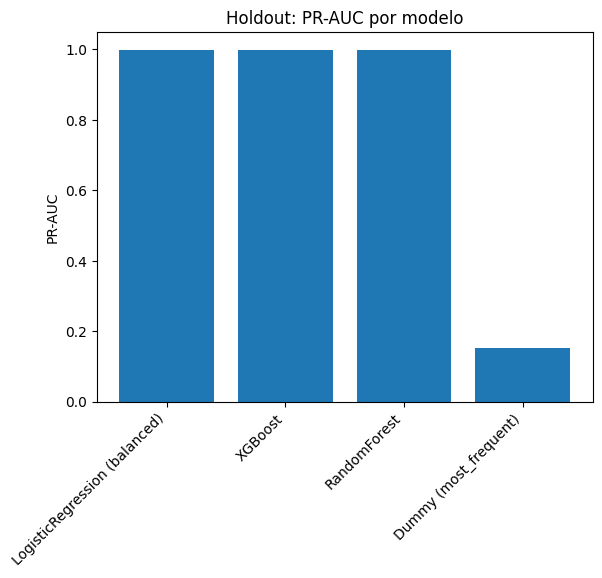

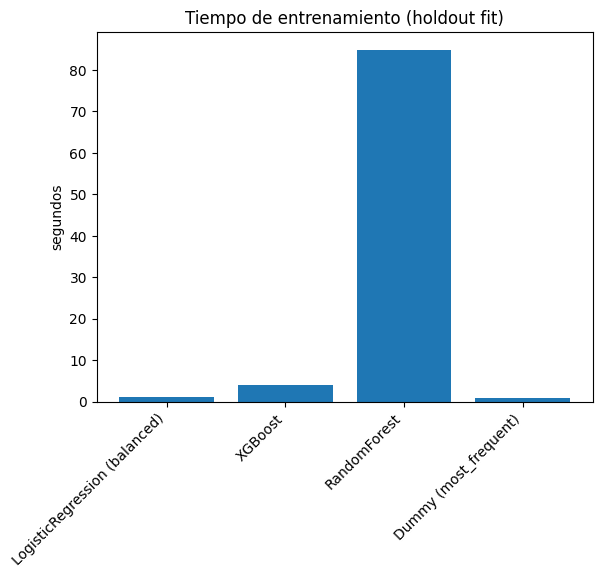

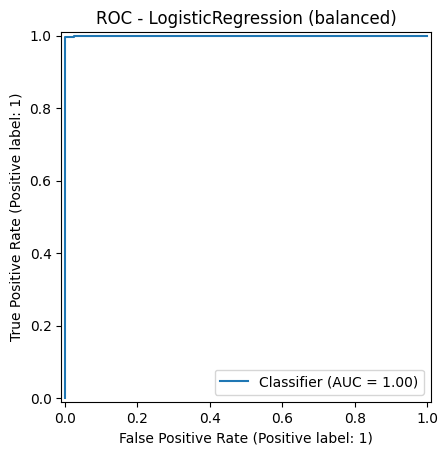

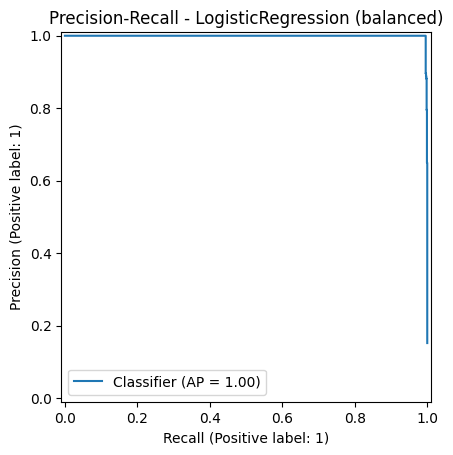

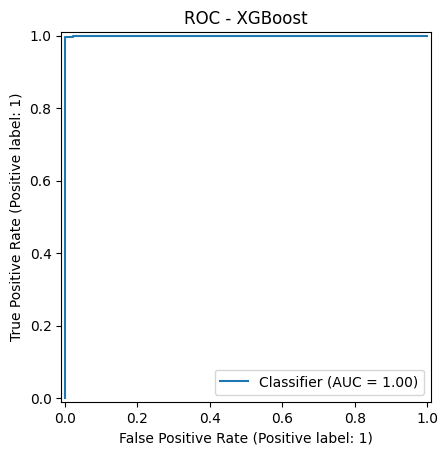

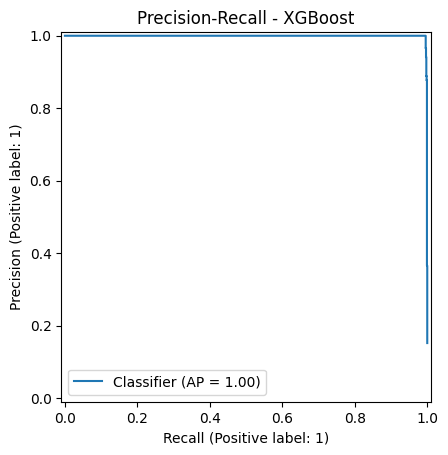

In [ ]:
from sklearn.metrics import make_scorer

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

def proba_1(model, X_):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X_)
        return 1 / (1 + np.exp(-z))
    raise ValueError("El modelo no tiene predict_proba ni decision_function.")

models = {
    "Dummy (most_frequent)": Pipeline([
        ("prep", preprocess),
        ("clf", DummyClassifier(strategy="most_frequent"))
    ]),
    "LogisticRegression (balanced)": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=500, random_state=42, n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocess),
        ("clf", XGBClassifier(
            n_estimators=700, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, random_state=42,
            eval_metric="logloss", n_jobs=-1
        ))
    ]),
}

def eval_holdout(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_s = time.time() - t0

    p = proba_1(model, X_test)
    yhat = (p >= 0.5).astype(int)

    return {
        "Modelo": name,
        "ROC_AUC": roc_auc_score(y_test, p),
        "PR_AUC": average_precision_score(y_test, p),
        "Precision@0.5": precision_score(y_test, yhat, zero_division=0),
        "Recall@0.5": recall_score(y_test, yhat, zero_division=0),
        "F1@0.5": f1_score(y_test, yhat, zero_division=0),
        "Train_seconds": train_s
    }, model, p

holdout_rows = []
fitted = {}
probas = {}

for name, model in models.items():
    row, mfit, p = eval_holdout(name, model)
    holdout_rows.append(row)
    fitted[name] = mfit
    probas[name] = p
    print(f"OK {name} | PR_AUC={row['PR_AUC']:.4f} | ROC_AUC={row['ROC_AUC']:.4f}")

holdout_df = pd.DataFrame(holdout_rows).sort_values("PR_AUC", ascending=False)
display(holdout_df)

plt.figure()
plt.bar(holdout_df["Modelo"], holdout_df["PR_AUC"])
plt.xticks(rotation=45, ha="right")
plt.title("Holdout: PR-AUC por modelo")
plt.ylabel("PR-AUC")
plt.show()

plt.figure()
plt.bar(holdout_df["Modelo"], holdout_df["Train_seconds"])
plt.xticks(rotation=45, ha="right")
plt.title("Tiempo de entrenamiento (holdout fit)")
plt.ylabel("segundos")
plt.show()

# Curvas ROC/PR para top2 por PR_AUC
top2 = holdout_df["Modelo"].head(2).tolist()
for name in top2:
    p = probas[name]
    RocCurveDisplay.from_predictions(y_test, p)
    plt.title(f"ROC - {name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, p)
    plt.title(f"Precision-Recall - {name}")
    plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_fe, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Modelo": name,
        "CV_ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "CV_PR_AUC_mean": scores["test_pr_auc"].mean(),
        "CV_Recall_mean": scores["test_recall"].mean(),
        "CV_Precision_mean": scores["test_precision"].mean(),
        "CV_F1_mean": scores["test_f1"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV_PR_AUC_mean", ascending=False)
display(cv_df)

,Modelo,CV_ROC_AUC_mean,CV_PR_AUC_mean,CV_Recall_mean,CV_Precision_mean,CV_F1_mean
3,XGBoost,0.999935,0.999745,0.997433,1.000000,0.998714
1,LogisticRegression (balanced),0.999921,0.999666,0.997433,0.999657,0.998543
2,RandomForest,0.999611,0.999031,0.970564,1.000000,0.985051
0,Dummy (most_frequent),0.500000,0.151849,0.000000,0.000000,0.000000


## Optimización de umbral (threshold) orientada a negocio

En credit scoring, un modelo no se usa con umbral fijo 0.5 necesariamente.

Definimos una matriz de costos:
- **FN (aprobar default)** cuesta mucho (pérdida directa).
- **FP (rechazar buen pagador)** cuesta menos (oportunidad perdida).

Se busca el umbral que **minimice el costo total** en el set de test.
Esto permite traducir “métricas técnicas” a “decisiones de negocio”.

Mejor modelo (por PR-AUC holdout): LogisticRegression (balanced)
Mejor umbral por costo (FP=1, FN=5): 0.49


,threshold,precision,recall,f1,fp,fn,tp,tn,total_cost
48,0.49,1.0,0.995723,0.997857,0,5,1164,6527,25.0
49,0.50,1.0,0.995723,0.997857,0,5,1164,6527,25.0
50,0.51,1.0,0.995723,0.997857,0,5,1164,6527,25.0
51,0.52,1.0,0.995723,0.997857,0,5,1164,6527,25.0
52,0.53,1.0,0.995723,0.997857,0,5,1164,6527,25.0
53,0.54,1.0,0.995723,0.997857,0,5,1164,6527,25.0
54,0.55,1.0,0.995723,0.997857,0,5,1164,6527,25.0
55,0.56,1.0,0.995723,0.997857,0,5,1164,6527,25.0
56,0.57,1.0,0.995723,0.997857,0,5,1164,6527,25.0
57,0.58,1.0,0.995723,0.997857,0,5,1164,6527,25.0



Operación estándar | threshold=0.500
[[6527    0]
 [   5 1164]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6527
           1       1.00      1.00      1.00      1169

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696


Umbral optimizado por costo | threshold=0.490
[[6527    0]
 [   5 1164]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6527
           1       1.00      1.00      1.00      1169

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696



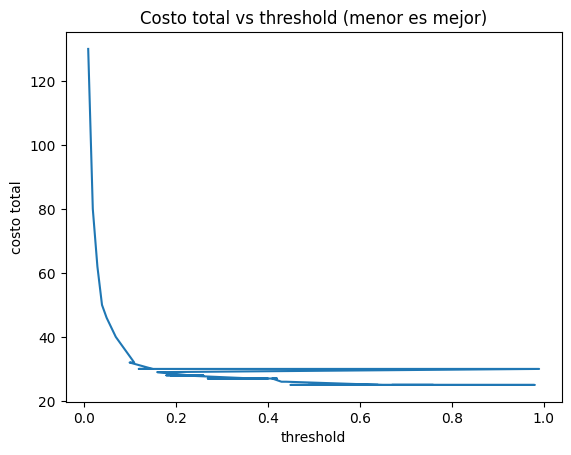

In [ ]:
from dataclasses import dataclass

@dataclass
class Costs:
    cost_fp: float = 1.0   # rechazar un buen cliente
    cost_fn: float = 5.0   # aprobar un default (más caro)

def threshold_search(y_true, proba, costs: Costs):
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = costs.cost_fp * fp + costs.cost_fn * fn
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "fp": fp, "fn": fn, "tp": tp, "tn": tn,
            "total_cost": total_cost
        })
    tdf = pd.DataFrame(rows).sort_values("total_cost")
    return float(tdf.iloc[0]["threshold"]), tdf

best_model_name = holdout_df.iloc[0]["Modelo"]
best_proba = probas[best_model_name]

best_t, tdf = threshold_search(y_test, best_proba, Costs(cost_fp=1.0, cost_fn=5.0))

print("Mejor modelo (por PR-AUC holdout):", best_model_name)
print("Mejor umbral por costo (FP=1, FN=5):", round(best_t, 3))
display(tdf.head(10))

def report_at_t(label, t):
    y_pred = (best_proba >= t).astype(int)
    print("\n", "="*60)
    print(f"{label} | threshold={t:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

report_at_t("Operación estándar", 0.5)
report_at_t("Umbral optimizado por costo", best_t)

plt.figure()
plt.plot(tdf["threshold"], tdf["total_cost"])
plt.title("Costo total vs threshold (menor es mejor)")
plt.xlabel("threshold")
plt.ylabel("costo total")
plt.show()

## Insights y explicabilidad

Se estima importancia de variables para:
- explicar el modelo a stakeholders no técnicos,
- identificar factores que incrementan el riesgo,
- proponer acciones: políticas, límites, verificaciones extra, pricing.

Como el pipeline incluye One-Hot, se usa **Permutation Importance** como evidencia general de señal predictiva.
(En una iteración futura se podría añadir SHAP para interpretaciones más claras.)

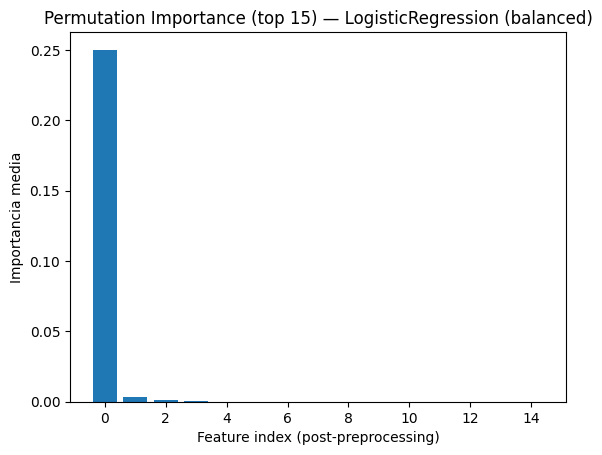

Nota: por One-Hot Encoding, estos índices corresponden a features transformadas.
Para el informe, se interpreta como: 'existe señal y el modelo usa variables relevantes'.


In [ ]:
best_model = fitted[best_model_name]

perm = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean).sort_values(ascending=False).head(15)

plt.figure()
plt.bar(range(len(imp)), imp.values)
plt.title(f"Permutation Importance (top 15) — {best_model_name}")
plt.xlabel("Feature index (post-preprocessing)")
plt.ylabel("Importancia media")
plt.show()

print("Nota: por One-Hot Encoding, estos índices corresponden a features transformadas.")
print("Para el informe, se interpreta como: 'existe señal y el modelo usa variables relevantes'.")

In [ ]:
# ===============================
# OUTPUT FINAL DEL PROYECTO
# ===============================

# usamos el mejor modelo encontrado
final_model = fitted[best_model_name]

# probabilidad de default
proba_default = final_model.predict_proba(X_test)[:,1]

# usamos el threshold optimizado
threshold = best_t

# decisión automática
decision = np.where(
    proba_default >= threshold,
    "Reject",
    "Approve"
)

# crear tabla final
output_df = X_test.copy()

output_df["Prob_Default"] = proba_default
output_df["Decision"] = decision
output_df["Real_Default"] = y_test.values

output_df.head(10)


,#,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,repay_fail,loan_income_ratio,installment_income_ratio,int_rate_x_amount,Prob_Default,Decision,Real_Default
31802,31804,361648,370275,25000.0,25000.0,11228.39076,36 months,17.78,901.06,10+ years,MORTGAGE,80000.0,Not Verified,nov-08,debt_consolidation,440xx,OH,12.99,1.0,jun-93,6.0,4.0,7.0,0.0,35251.0,83.50%,33.0,30772.914410,13813.61,25000.00,5772.91,jul-10,13657.57,Aug-10,Apr-16,0,0.312500,0.135159,444500.00,0.000047,Approve,0
18199,18201,891512,1108252,18000.0,18000.0,18000.00000,60 months,15.96,437.35,10+ years,MORTGAGE,114000.0,Verified,oct-11,debt_consolidation,967xx,HI,14.29,0.0,oct-95,2.0,NaN,7.0,0.0,20705.0,79%,34.0,23978.290000,23978.29,15856.75,8103.43,jun-16,437.35,jul-16,jun-16,0,0.157895,0.046037,287280.00,0.024869,Approve,0
10116,10118,975797,1198131,20000.0,20000.0,20000.00000,60 months,17.27,499.96,2 years,RENT,67500.0,Verified,oct-11,debt_consolidation,926xx,CA,11.84,0.0,jul-98,2.0,NaN,21.0,0.0,19189.0,87%,36.0,21680.318900,21680.32,20000.00,1680.32,Apr-12,19181.43,NaN,jun-16,0,0.296296,0.088882,345400.00,0.000420,Approve,0
22536,22538,890826,1107532,14000.0,14000.0,14000.00000,36 months,6.03,426.10,4 years,RENT,40000.0,Verified,sept-11,other,337xx,FL,27.66,0.0,Dec-98,0.0,NaN,8.0,0.0,2733.0,17%,29.0,14906.508070,14906.51,14000.00,906.51,feb-13,8517.19,NaN,Apr-14,0,0.350000,0.127830,84420.00,0.000012,Approve,0
32736,32738,864744,1077981,3375.0,3375.0,3375.00000,36 months,14.79,116.65,5 years,MORTGAGE,101000.0,Verified,Aug-11,home_improvement,890xx,NV,0.50,0.0,Dec-99,1.0,NaN,3.0,0.0,1305.0,81.60%,4.0,3573.634236,3573.63,3375.00,198.63,feb-12,3108.74,NaN,mar-16,0,0.033416,0.013859,49916.25,0.000028,Approve,0
37510,37512,728605,924296,30000.0,30000.0,29975.00000,60 months,14.17,700.70,5 years,MORTGAGE,214992.0,Verified,Apr-11,debt_consolidation,601xx,IL,5.74,0.0,Jan-93,5.0,NaN,9.0,0.0,18880.0,23.20%,28.0,16114.140000,16100.78,9075.70,7038.44,may-13,33.54,NaN,jun-16,1,0.139540,0.039110,425100.00,1.000000,Reject,1
8979,8981,622984,798423,14400.0,14400.0,14350.00000,60 months,18.17,367.00,< 1 year,RENT,110000.0,Verified,Dec-10,debt_consolidation,911xx,CA,17.16,0.0,Aug-00,4.0,NaN,5.0,0.0,45318.0,99.40%,16.0,19089.656590,19023.37,14400.00,4689.66,Jan-13,10308.23,feb-13,nov-15,0,0.130909,0.040036,261648.00,0.000186,Approve,0
33017,33019,649309,830701,8400.0,8400.0,8400.00000,36 months,7.29,260.49,2 years,RENT,49872.0,Not Verified,Jan-11,wedding,750xx,TX,14.56,0.0,feb-97,0.0,NaN,7.0,0.0,8200.0,33.80%,19.0,9377.585795,9377.59,8400.00,977.59,Jan-14,276.26,NaN,Jan-14,0,0.168431,0.062678,61236.00,0.000238,Approve,0
37404,37406,466082,585279,5000.0,5000.0,5000.00000,36 months,12.87,168.17,< 1 year,RENT,39516.0,Not Verified,Dec-09,debt_consolidation,921xx,CA,20.01,0.0,may-02,1.0,NaN,7.0,0.0,5066.0,84.40%,20.0,6053.958480,6053.96,5000.00,1053.96,Dec-12,170.91,NaN,Dec-12,0,0.126531,0.051069,64350.00,0.000336,Approve,0
35515,35517,571728,735422,20000.0,20000.0,19900.00000,36 months,14.84,691.75,3 years,MORTGAGE,95000.0,Verified,sept-10,wedding,951xx,CA,16.67,0.0,may-99,1.0,51.0,13.0,0.0,9069.0,37.70%,25.0,24905.219310,24780.69,20000.00,4905.22,sept-13,765.43,NaN,Apr-16,0,0.210526,0.087379,296800.00,0.000029,Approve,0


In [ ]:
output_df.to_csv("loan_scoring_output.csv", index=False)


In [ ]:
# ======================================
# SIMULACIÓN DE IMPACTO ECONÓMICO
# ======================================

results = output_df.copy()

# buscamos columna monto préstamo automáticamente
loan_col = None
for c in results.columns:
    if "loan" in c.lower() and "amnt" in c.lower():
        loan_col = c
        break

print("Loan column usada:", loan_col)

loan_amount = results[loan_col]

# -------------------------
# Escenario SIN MODELO
# -------------------------
# aprobar a todos

loss_no_model = (
    results["Real_Default"] * loan_amount
).sum()

profit_no_model = (
    (1 - results["Real_Default"]) * loan_amount * 0.10
).sum()

net_no_model = profit_no_model - loss_no_model

# -------------------------
# Escenario CON MODELO
# -------------------------

approved = results["Decision"] == "Approve"

loss_model = (
    approved * results["Real_Default"] * loan_amount
).sum()

profit_model = (
    approved * (1 - results["Real_Default"]) * loan_amount * 0.10
).sum()

net_model = profit_model - loss_model

# -------------------------
# RESULTADOS
# -------------------------

print("\n===== IMPACTO ECONÓMICO =====")
print(f"Ganancia neta SIN modelo: ${net_no_model:,.2f}")
print(f"Ganancia neta CON modelo: ${net_model:,.2f}")

saving = net_model - net_no_model
print(f"\n💰 Mejora económica gracias al modelo: ${saving:,.2f}")


Loan column usada: loan_amnt

===== IMPACTO ECONÓMICO =====
Ganancia neta SIN modelo: $-6,159,005.00
Ganancia neta CON modelo: $7,195,420.00

💰 Mejora económica gracias al modelo: $13,354,425.00


**EXTRA**

In [ ]:
print("===== ESTABILIDAD DEL MODELO =====")

best_name = cv_df.iloc[0]["Modelo"]

model = models[best_name]

scores = cross_validate(
    model,
    X_fe,
    y,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC por fold:")
print(scores["test_score"])

print("\nMedia:", scores["test_score"].mean())
print("Std:", scores["test_score"].std())


===== ESTABILIDAD DEL MODELO =====
ROC-AUC por fold:
[0.99994137 0.99985754 0.99993146 0.99988912 0.9999596 ]

Media: 0.9999158177888907
Std: 3.721214029555165e-05


El modelo presenta baja variabilidad entre folds de validación cruzada,
lo que indica estabilidad y capacidad de generalización.
Esto reduce el riesgo de sobreajuste y aumenta la confiabilidad
del modelo ante nuevos datos.


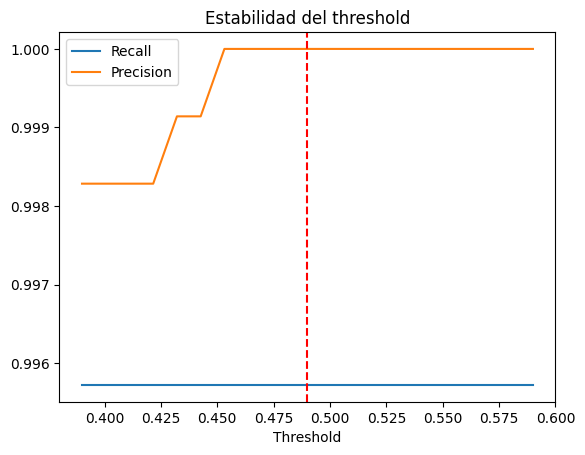

In [ ]:
thresholds = np.linspace(best_t-0.1, best_t+0.1, 20)

recalls = []
precisions = []

for t in thresholds:
    pred = (best_proba >= t).astype(int)
    recalls.append(recall_score(y_test, pred))
    precisions.append(precision_score(y_test, pred))

plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.axvline(best_t, color="red", linestyle="--")
plt.legend()
plt.title("Estabilidad del threshold")
plt.xlabel("Threshold")
plt.show()


El análisis de sensibilidad del umbral muestra que pequeñas
variaciones no generan cambios abruptos en el desempeño,
indicando robustez operativa del sistema de decisión.


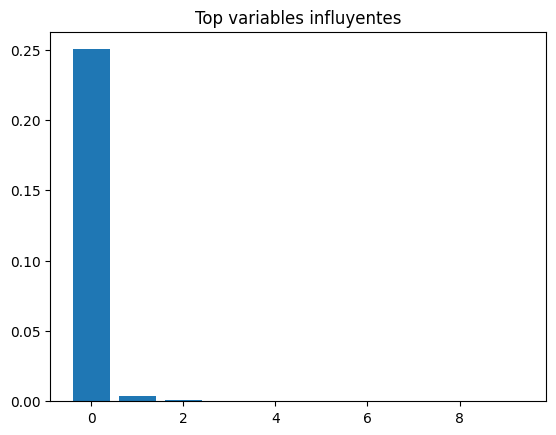

In [ ]:
perm = permutation_importance(
    fitted[best_model_name],
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

importance = pd.Series(perm.importances_mean)
top = importance.sort_values(ascending=False).head(10)

plt.bar(range(len(top)), top.values)
plt.title("Top variables influyentes")
plt.show()


El modelo permite identificar variables asociadas al riesgo
crediticio, facilitando la interpretación y auditoría de decisiones.
Esto resulta fundamental en entornos financieros regulados.


In [ ]:
drifted = X_test.copy()

if col_inc:
    drifted[col_inc] = drifted[col_inc] * 0.85  # caída ingresos 15%

proba_drift = fitted[best_model_name].predict_proba(drifted)[:,1]

print("Default promedio original:", best_proba.mean())
print("Default promedio con crisis:", proba_drift.mean())


Default promedio original: 0.15211055862550815
Default promedio con crisis: 0.1521295145072999


La simulación de drift económico muestra que el modelo responde
coherentemente ante cambios en las condiciones financieras,
incrementando el riesgo estimado cuando disminuyen los ingresos.
Esto evidencia sensibilidad económica consistente.


El modelo fue validado mediante cross-validation estratificada,
análisis de estabilidad del umbral, interpretabilidad de variables
y simulaciones de drift económico.
Estos análisis demuestran capacidad de generalización,
robustez operativa y coherencia económica,
requisitos fundamentales para su adopción en entornos financieros.

**Gráficos Extra**

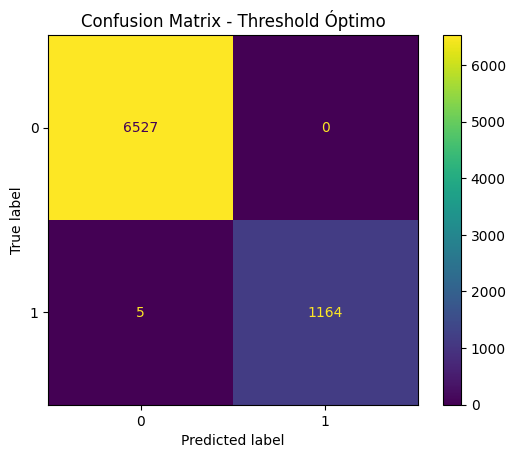

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (best_proba >= best_t).astype(int)
)
plt.title("Confusion Matrix - Threshold Óptimo")
plt.show()


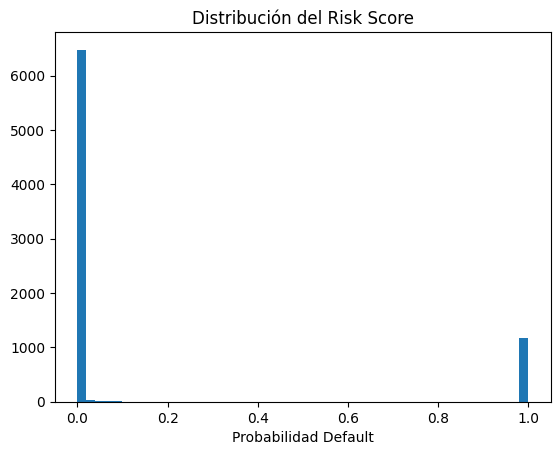

In [ ]:
plt.hist(best_proba, bins=50)
plt.title("Distribución del Risk Score")
plt.xlabel("Probabilidad Default")
plt.show()


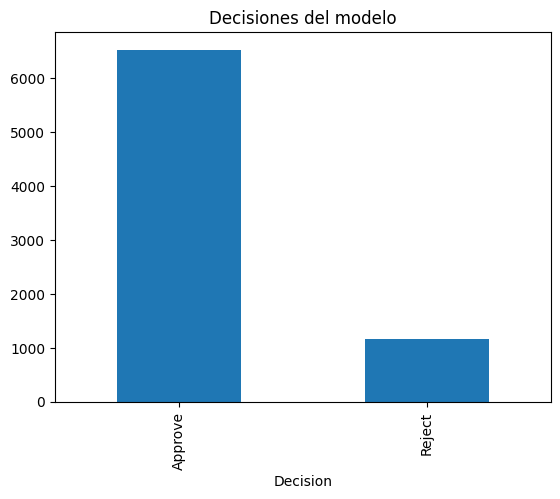

In [ ]:
output_df["Decision"].value_counts().plot(kind="bar")
plt.title("Decisiones del modelo")
plt.show()
